In [2]:
import sympy as sp

# =========================
# Symbols
# =========================

Eb = sp.symbols("E_b", real=True)

B20, B40, B43, B44 = sp.symbols("B20 B40 B43 B44", real=True)

sqrt = sp.sqrt

In [3]:
# =========================
# D3 ket ordering:
# |5/2>, |1/2>, |-1/2>, |3/2>, |-5/2>, |-3/2>
# =========================

m_vals_D3 = [
    sp.Rational(5, 2),
    sp.Rational(1, 2),
    sp.Rational(-1, 2),
    sp.Rational(3, 2),
    sp.Rational(-5, 2),
    sp.Rational(-3, 2),
]

Sz_D3 = sp.diag(*m_vals_D3)
sp.pretty_print(Sz_D3)

⎡5/2   0    0     0    0     0  ⎤
⎢                               ⎥
⎢ 0   1/2   0     0    0     0  ⎥
⎢                               ⎥
⎢ 0    0   -1/2   0    0     0  ⎥
⎢                               ⎥
⎢ 0    0    0    3/2   0     0  ⎥
⎢                               ⎥
⎢ 0    0    0     0   -5/2   0  ⎥
⎢                               ⎥
⎣ 0    0    0     0    0    -3/2⎦


In [4]:
# =========================
# D3 Hamiltonian
# =========================

A_D3 = 10*B20 - 60*B40
D_D3 = -8*B20 - 120*B40
F_D3 = -2*B20 - 120*B40
V_D3 = 3*sqrt(10)*B43

H_D3 = sp.Matrix([
    [A_D3, 0,    0,    0,    V_D3, 0],
    [0,    D_D3,0,    0,    0,    0],
    [0,    0,    F_D3,0,    0,    0],
    [0,    0,    0,    A_D3,0,    0],
    [V_D3,0,    0,    0,    D_D3,0],
    [0,    0,    0,    0,    0,    F_D3],
])

H_D3_field = H_D3 - Eb*Sz_D3

print("D3 field-dependent Hamiltonian:")
sp.pretty_print(H_D3_field)

D3 field-dependent Hamiltonian:
⎡                  5⋅E_b                                                      
⎢10⋅B₂₀ - 60⋅B₄₀ - ─────            0                       0                 
⎢                    2                                                        
⎢                                                                             
⎢                                            E_b                              
⎢           0             -8⋅B₂₀ - 120⋅B₄₀ - ───            0                 
⎢                                             2                               
⎢                                                                             
⎢                                                                    E_b      
⎢           0                       0             -2⋅B₂₀ - 120⋅B₄₀ + ───      
⎢                                                                     2       
⎢                                                                             
⎢                   

In [5]:
# =========================
# D3 analytic eigenvalues
# =========================

a_D3 = A_D3 - sp.Rational(5, 2)*Eb
d_D3 = D_D3 + sp.Rational(5, 2)*Eb

lambda_D3_minus = sp.simplify(
    (a_D3 + d_D3)/2 - sp.sqrt(((a_D3 - d_D3)/2)**2 + V_D3**2)
)

lambda_D3_plus = sp.simplify(
    (a_D3 + d_D3)/2 + sp.sqrt(((a_D3 - d_D3)/2)**2 + V_D3**2)
)

# Uncoupled states
lambda_D3_2 = sp.simplify(D_D3 - sp.Rational(1, 2)*Eb)  # |1/2>
lambda_D3_3 = sp.simplify(F_D3 + sp.Rational(1, 2)*Eb)  # |-1/2>
lambda_D3_4 = sp.simplify(A_D3 - sp.Rational(3, 2)*Eb)  # |3/2>
lambda_D3_6 = sp.simplify(F_D3 + sp.Rational(3, 2)*Eb)  # |-3/2>

D3_eigs = [
    lambda_D3_minus,
    lambda_D3_plus,
    lambda_D3_2,
    lambda_D3_3,
    lambda_D3_4,
    lambda_D3_6,
]

for i, lam in enumerate(D3_eigs, start=1):
    print(f"\nD3 eigenvalue {i}:")
    sp.pretty_print(sp.simplify(lam))


D3 eigenvalue 1:
                  _______________________________________
                 ╱        2                            2 
               ╲╱  360⋅B₄₃  + (18⋅B₂₀ + 60⋅B₄₀ - 5⋅E_b)  
B₂₀ - 90⋅B₄₀ - ──────────────────────────────────────────
                                   2                     

D3 eigenvalue 2:
                  _______________________________________
                 ╱        2                            2 
               ╲╱  360⋅B₄₃  + (18⋅B₂₀ + 60⋅B₄₀ - 5⋅E_b)  
B₂₀ - 90⋅B₄₀ + ──────────────────────────────────────────
                                   2                     

D3 eigenvalue 3:
                   E_b
-8⋅B₂₀ - 120⋅B₄₀ - ───
                    2 

D3 eigenvalue 4:
                   E_b
-2⋅B₂₀ - 120⋅B₄₀ + ───
                    2 

D3 eigenvalue 5:
                  3⋅E_b
10⋅B₂₀ - 60⋅B₄₀ - ─────
                    2  

D3 eigenvalue 6:
                   3⋅E_b
-2⋅B₂₀ - 120⋅B₄₀ + ─────
                     2  


In [6]:
# =========================
# D3 crossing field and avoided gap
# =========================

Eb_cross_D3 = sp.simplify(sp.solve(sp.Eq(a_D3, d_D3), Eb)[0])
gap_D3 = sp.simplify(6*sqrt(10)*sp.Abs(B43))

print("\nD3 bare crossing field:")
sp.pretty_print(Eb_cross_D3)

print("\nD3 avoided-crossing gap:")
sp.pretty_print(gap_D3)


D3 bare crossing field:
18⋅B₂₀         
────── + 12⋅B₄₀
  5            

D3 avoided-crossing gap:
6⋅√10⋅│B₄₃│


In [7]:
# =========================
# D2/D4 ket ordering:
# |5/2>, |1/2>, |-3/2>, |-5/2>, |-1/2>, |3/2>
# =========================

m_vals_D2_D4 = [
    sp.Rational(5, 2),
    sp.Rational(1, 2),
    sp.Rational(-3, 2),
    sp.Rational(-5, 2),
    sp.Rational(-1, 2),
    sp.Rational(3, 2),
]

Sz_D2_D4 = sp.diag(*m_vals_D2_D4)

In [8]:
# =========================
# D4 Hamiltonian
# =========================

A_D4 = 10*B20 - 60*B40
D_D4 = -8*B20 - 120*B40
F_D4 = -2*B20 + 180*B40
C_D4 = 12*sqrt(5)*B44

d4 = sp.Matrix([
    [A_D4, 0,    C_D4],
    [0,    D_D4,0],
    [C_D4,0,    F_D4],
])

zero3 = sp.zeros(3, 3)

H_D4 = sp.Matrix.vstack(
    sp.Matrix.hstack(d4, zero3),
    sp.Matrix.hstack(zero3, d4)
)

H_D4_field = H_D4 - Eb*Sz_D2_D4

print("\nD4 field-dependent Hamiltonian:")
sp.pretty_print(H_D4_field)


D4 field-dependent Hamiltonian:
⎡                  5⋅E_b                                                      
⎢10⋅B₂₀ - 60⋅B₄₀ - ─────            0                    12⋅√5⋅B₄₄            
⎢                    2                                                        
⎢                                                                             
⎢                                            E_b                              
⎢           0             -8⋅B₂₀ - 120⋅B₄₀ - ───             0                
⎢                                             2                               
⎢                                                                             
⎢                                                                    3⋅E_b    
⎢       12⋅√5⋅B₄₄                   0             -2⋅B₂₀ + 180⋅B₄₀ + ─────    
⎢                                                                      2      
⎢                                                                             
⎢                  

In [9]:
# =========================
# D4 analytic eigenvalues
# =========================

# Block 1: |5/2> and |-3/2>
a1_D4 = A_D4 - sp.Rational(5, 2)*Eb
f1_D4 = F_D4 + sp.Rational(3, 2)*Eb

lambda_D4_1_minus = sp.simplify(
    (a1_D4 + f1_D4)/2 - sp.sqrt(((a1_D4 - f1_D4)/2)**2 + C_D4**2)
)

lambda_D4_1_plus = sp.simplify(
    (a1_D4 + f1_D4)/2 + sp.sqrt(((a1_D4 - f1_D4)/2)**2 + C_D4**2)
)

# Block 2: |-5/2> and |3/2>
a2_D4 = A_D4 + sp.Rational(5, 2)*Eb
f2_D4 = F_D4 - sp.Rational(3, 2)*Eb

lambda_D4_2_minus = sp.simplify(
    (a2_D4 + f2_D4)/2 - sp.sqrt(((a2_D4 - f2_D4)/2)**2 + C_D4**2)
)

lambda_D4_2_plus = sp.simplify(
    (a2_D4 + f2_D4)/2 + sp.sqrt(((a2_D4 - f2_D4)/2)**2 + C_D4**2)
)

# Uncoupled levels
lambda_D4_uncoupled_1 = sp.simplify(D_D4 - sp.Rational(1, 2)*Eb)  # |1/2>
lambda_D4_uncoupled_2 = sp.simplify(D_D4 + sp.Rational(1, 2)*Eb)  # |-1/2>

D4_eigs = [
    lambda_D4_1_minus,
    lambda_D4_1_plus,
    lambda_D4_2_minus,
    lambda_D4_2_plus,
    lambda_D4_uncoupled_1,
    lambda_D4_uncoupled_2,
]

for i, lam in enumerate(D4_eigs, start=1):
    print(f"\nD4 eigenvalue {i}:")
    sp.pretty_print(sp.simplify(lam))


D4 eigenvalue 1:
                            _____________________________________
                 E_b       ╱        2                          2 
4⋅B₂₀ + 60⋅B₄₀ - ─── - 2⋅╲╱  180⋅B₄₄  + (-3⋅B₂₀ + 60⋅B₄₀ + E_b)  
                  2                                              

D4 eigenvalue 2:
                            _____________________________________
                 E_b       ╱        2                          2 
4⋅B₂₀ + 60⋅B₄₀ - ─── + 2⋅╲╱  180⋅B₄₄  + (-3⋅B₂₀ + 60⋅B₄₀ + E_b)  
                  2                                              

D4 eigenvalue 3:
                            ____________________________________
                 E_b       ╱        2                         2 
4⋅B₂₀ + 60⋅B₄₀ + ─── - 2⋅╲╱  180⋅B₄₄  + (3⋅B₂₀ - 60⋅B₄₀ + E_b)  
                  2                                             

D4 eigenvalue 4:
                            ____________________________________
                 E_b       ╱        2                         2 
4⋅B₂₀ + 60

In [11]:
# =========================
# D4 crossing fields and avoided gap
# =========================

Eb_cross_D4_block1 = sp.simplify(sp.solve(sp.Eq(a1_D4, f1_D4), Eb)[0])
Eb_cross_D4_block2 = sp.simplify(sp.solve(sp.Eq(a2_D4, f2_D4), Eb)[0])

gap_D4 = sp.simplify(24*sqrt(5)*sp.Abs(B44))

print("\nD4 block 1 bare crossing field:")
sp.pretty_print(Eb_cross_D4_block1)

print("\nD4 block 2 bare crossing field:")
sp.pretty_print(Eb_cross_D4_block2)

print("\nD4 avoided-crossing gap:")
sp.pretty_print(gap_D4)


D4 block 1 bare crossing field:
3⋅B₂₀ - 60⋅B₄₀

D4 block 2 bare crossing field:
-3⋅B₂₀ + 60⋅B₄₀

D4 avoided-crossing gap:
24⋅√5⋅│B₄₄│


In [12]:
# =========================
# Lambdify analytic expressions
# =========================

D3_eigs_func = [
    sp.lambdify((Eb, B20, B40, B43), expr, "numpy")
    for expr in D3_eigs
]

D4_eigs_func = [
    sp.lambdify((Eb, B20, B40, B44), expr, "numpy")
    for expr in D4_eigs
]

Eb_cross_D3_func = sp.lambdify((B20, B40), Eb_cross_D3, "numpy")
gap_D3_func = sp.lambdify((B43,), 6*sqrt(10)*sp.Abs(B43), "numpy")

Eb_cross_D4_block1_func = sp.lambdify((B20, B40), Eb_cross_D4_block1, "numpy")
Eb_cross_D4_block2_func = sp.lambdify((B20, B40), Eb_cross_D4_block2, "numpy")
gap_D4_func = sp.lambdify((B44,), 24*sqrt(5)*sp.Abs(B44), "numpy")

In [18]:
def plot_analytic_levels_sorted(eigs_func, params, title, Eb_min=0, Eb_max=10, n=1000):
    Eb_grid = np.linspace(Eb_min, Eb_max, n)

    # levels shape before sorting: (n_levels, n_Eb)
    levels = np.array([
        f(Eb_grid, *params)
        for f in eigs_func
    ])

    # transpose to (n_Eb, n_levels), sort each field row, then transpose back
    levels_sorted = np.sort(levels.T, axis=1).T

    plt.figure(figsize=(8, 5))

    for i in range(levels_sorted.shape[0]):
        plt.plot(Eb_grid, levels_sorted[i], label=f"Level {i+1}")

    plt.xlabel(r"$E_b$")
    plt.ylabel("Analytic eigenvalue")
    plt.title(title + " sorted by energy")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.show()

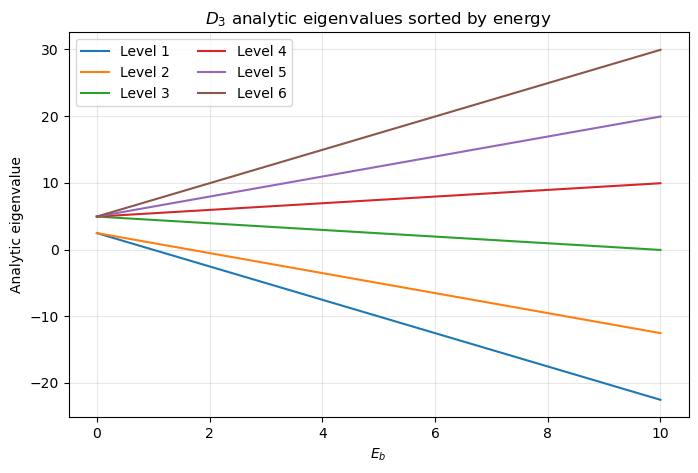

D3 bare crossing field:
-0.49407192
D3 avoided-crossing gap:
0.18973665961010278


In [20]:
# Example D3 values
B20_val = 0.0
B40_val = -0.04117266
B43_val = 0.01

plot_analytic_levels_sorted(
    D3_eigs_func,
    params=(B20_val, B40_val, B43_val),
    title=r"$D_3$ analytic eigenvalues",
    Eb_min=0,
    Eb_max=10,
)
print("D3 bare crossing field:")
print(Eb_cross_D3_func(B20_val, B40_val))

print("D3 avoided-crossing gap:")
print(gap_D3_func(B43_val))

In [16]:
import numpy as np

def find_avoided_crossing_gaps(eigs_func, params, Eb_min=0, Eb_max=10, n=5000, top_k=5):
    """
    Finds the smallest pairwise gaps between analytic eigenvalue branches.
    
    Returns a list of candidate avoided crossings:
    branch pair, field location, minimum gap.
    """
    Eb_grid = np.linspace(Eb_min, Eb_max, n)

    # levels shape: (n_levels, n_Eb)
    levels = np.array([
        f(Eb_grid, *params)
        for f in eigs_func
    ])

    candidates = []

    n_levels = levels.shape[0]

    for i in range(n_levels):
        for j in range(i + 1, n_levels):
            gap = np.abs(levels[i] - levels[j])
            idx = np.argmin(gap)

            candidates.append({
                "pair": (i + 1, j + 1),
                "Eb": Eb_grid[idx],
                "gap": gap[idx],
            })

    # Sort by smallest minimum gap
    candidates = sorted(candidates, key=lambda x: x["gap"])

    return candidates[:top_k]

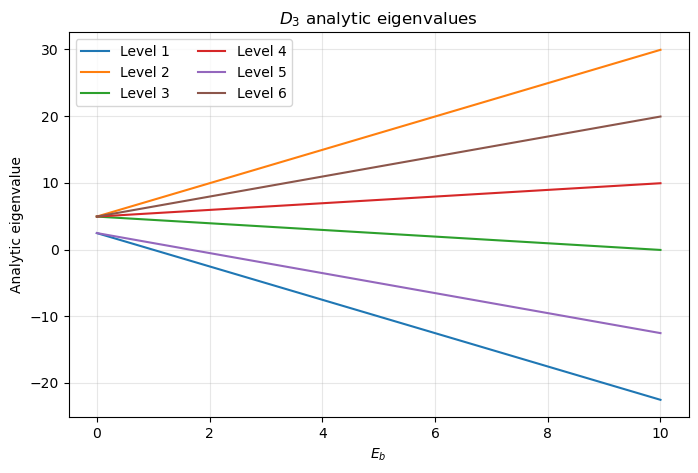

D3 bare crossing field:
-0.49407192
D3 primary avoided-crossing gap:
0.18973665961010278

Smallest pairwise gaps in plotted range:
1: Levels 3 and 4 | Eb = 0.000000 | gap = 0.000000e+00
2: Levels 3 and 6 | Eb = 0.000000 | gap = 0.000000e+00
3: Levels 4 and 6 | Eb = 0.000000 | gap = 0.000000e+00
4: Levels 1 and 5 | Eb = 0.000000 | gap = 3.637837e-03
5: Levels 2 and 3 | Eb = 0.000000 | gap = 3.637837e-03
6: Levels 2 and 4 | Eb = 0.000000 | gap = 3.637837e-03


In [17]:
# Example D3 values
B20_val = 0.0
B40_val = -0.04117266
B43_val = 0.01

plot_analytic_levels(
    D3_eigs_func,
    params=(B20_val, B40_val, B43_val),
    title=r"$D_3$ analytic eigenvalues",
    Eb_min=0,
    Eb_max=10,
)

print("D3 bare crossing field:")
print(Eb_cross_D3_func(B20_val, B40_val))

print("D3 primary avoided-crossing gap:")
print(gap_D3_func(B43_val))

print("\nSmallest pairwise gaps in plotted range:")
gap_candidates = find_avoided_crossing_gaps(
    D3_eigs_func,
    params=(B20_val, B40_val, B43_val),
    Eb_min=0,
    Eb_max=10,
    n=10000,
    top_k=6
)

for k, item in enumerate(gap_candidates, start=1):
    print(
        f"{k}: Levels {item['pair'][0]} and {item['pair'][1]} | "
        f"Eb = {item['Eb']:.6f} | "
        f"gap = {item['gap']:.6e}"
    )

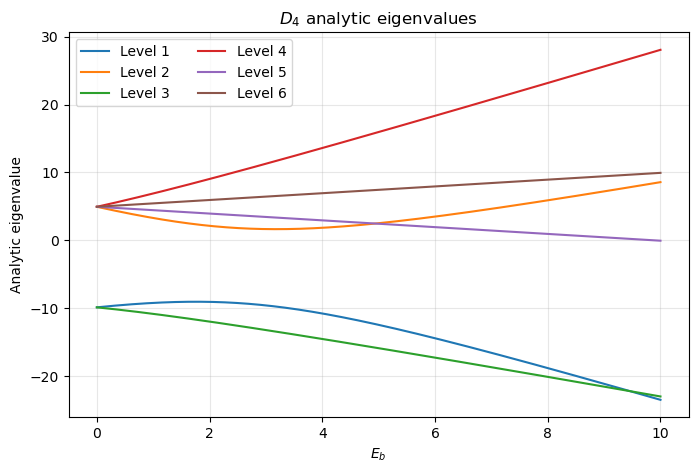

D4 block 1 bare crossing field:
2.4703596
D4 block 2 bare crossing field:
-2.4703596
D4 avoided-crossing gap:
11.047783971128313


In [15]:
# Example D4 values
B20_val = 0.0
B40_val = -0.04117266
B44_val = -0.205863299668129

plot_analytic_levels(
    D4_eigs_func,
    params=(B20_val, B40_val, B44_val),
    title=r"$D_4$ analytic eigenvalues",
    Eb_min=0,
    Eb_max=10,
)

print("D4 block 1 bare crossing field:")
print(Eb_cross_D4_block1_func(B20_val, B40_val))

print("D4 block 2 bare crossing field:")
print(Eb_cross_D4_block2_func(B20_val, B40_val))

print("D4 avoided-crossing gap:")
print(gap_D4_func(B44_val))

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# D3 analytic formulas
# ============================================================

def Eb_cross_D3(B20, B40):
    """
    Correct D3 bare crossing field.

    D3 mixed sector:
    |5/2> <--> |-5/2>

    Eb_cross = (18 B20 + 60 B40) / 5
    """
    return (18*B20 + 60*B40) / 5


def gap_D3(B43):
    """
    D3 avoided-crossing gap.

    V = 3 sqrt(10) B43
    Delta_min = 2|V| = 6 sqrt(10)|B43|
    """
    return 6*np.sqrt(10)*np.abs(B43)


def stevens_norm(B):
    """
    Overall Stevens-parameter scale.
    B = [B20, B40, B43]
    """
    B = np.asarray(B)
    return np.sqrt(np.sum(B**2))


def normalize_B(B):
    B = np.asarray(B, dtype=float)
    n = np.linalg.norm(B)
    if n == 0:
        raise ValueError("Cannot normalize zero vector.")
    return B / n

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# D3 analytic formulas
# ============================================================

def Eb_cross_D3(B20, B40):
    """
    Correct D3 bare crossing field.

    D3 mixed sector:
    |5/2> <--> |-5/2>

    Eb_cross = (18 B20 + 60 B40) / 5
    """
    return (18*B20 + 60*B40) / 5


def gap_D3(B43):
    """
    D3 avoided-crossing gap.

    V = 3 sqrt(10) B43
    Delta_min = 2|V| = 6 sqrt(10)|B43|
    """
    return 6*np.sqrt(10)*np.abs(B43)


def stevens_norm(B):
    """
    Overall Stevens-parameter scale.
    B = [B20, B40, B43]
    """
    B = np.asarray(B)
    return np.sqrt(np.sum(B**2))


def normalize_B(B):
    B = np.asarray(B, dtype=float)
    n = np.linalg.norm(B)
    if n == 0:
        raise ValueError("Cannot normalize zero vector.")
    return B / n

In [26]:
# ============================================================
# Objective functions
# ============================================================

def objective_minimize_crossing(B):
    """
    Minimize |Eb_cross|.
    This finds parameters where the bare crossing occurs
    at the smallest field.
    """
    B20, B40, B43 = B
    return np.abs(Eb_cross_D3(B20, B40))


def objective_minimize_crossing_with_gap_penalty(B, gap_target=0.25, weight_gap=1.0):
    """
    Minimize |Eb_cross| while encouraging a target avoided gap.

    This avoids the trivial B43 = 0 direct-crossing case
    if you want an actual avoided crossing.
    """
    B20, B40, B43 = B

    Eb0 = Eb_cross_D3(B20, B40)
    gap = gap_D3(B43)

    return np.abs(Eb0) + weight_gap * (gap - gap_target)**2

In [27]:
# ============================================================
# Constrained optimization
# ============================================================

def constraint_fixed_norm(B):
    """
    Enforces ||B|| = 1.
    """
    return np.sum(np.asarray(B)**2) - 1.0


def constraint_positive_crossing(B):
    """
    Enforces Eb_cross >= 0.
    """
    B20, B40, B43 = B
    return Eb_cross_D3(B20, B40)


def constraint_min_gap(B, gap_min):
    """
    Enforces Delta_min >= gap_min.
    """
    B20, B40, B43 = B
    return gap_D3(B43) - gap_min


def optimize_D3_min_crossing(
    gap_min=0.1,
    require_positive_field=True,
    x0=None,
    maxiter=1000,
):
    """
    Optimize D3 Stevens parameters to minimize the crossing field.

    Parameters
    ----------
    gap_min : float
        Minimum allowed avoided-crossing gap.
    require_positive_field : bool
        If True, require Eb_cross >= 0.
    x0 : array-like or None
        Initial guess [B20, B40, B43].
    """

    if x0 is None:
        x0 = np.array([0.5, -0.1, 0.5])
    x0 = normalize_B(x0)

    constraints = [
        {"type": "eq", "fun": constraint_fixed_norm},
        {"type": "ineq", "fun": lambda B: constraint_min_gap(B, gap_min)},
    ]

    if require_positive_field:
        constraints.append(
            {"type": "ineq", "fun": constraint_positive_crossing}
        )

    result = minimize(
        objective_minimize_crossing,
        x0,
        method="SLSQP",
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": maxiter}
    )

    return result

In [28]:
result = optimize_D3_min_crossing(
    gap_min=0.25,
    require_positive_field=True,
)

B20_opt, B40_opt, B43_opt = result.x

print("Optimization success:", result.success)
print("Message:", result.message)

print("\nOptimal normalized Stevens parameters:")
print(f"B20 = {B20_opt:.8f}")
print(f"B40 = {B40_opt:.8f}")
print(f"B43 = {B43_opt:.8f}")

print("\nDerived quantities:")
print(f"Eb_cross = {Eb_cross_D3(B20_opt, B40_opt):.8f}")
print(f"Gap      = {gap_D3(B43_opt):.8f}")
print(f"Norm     = {stevens_norm(result.x):.8f}")

Optimization success: False
Message: Iteration limit reached

Optimal normalized Stevens parameters:
B20 = 0.68320786
B40 = -0.20496236
B43 = 0.70087044

Derived quantities:
Eb_cross = -0.00000000
Gap      = 13.29808159
Norm     = 1.00000096


In [29]:
# ============================================================
# Random parameter scan
# ============================================================

def random_unit_vectors(n_samples, dim=3, seed=123):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n_samples, dim))
    X /= np.linalg.norm(X, axis=1)[:, None]
    return X


def scan_D3_parameter_space(
    n_samples=100000,
    gap_min=0.1,
    positive_field_only=True,
    seed=123,
):
    """
    Randomly samples normalized Stevens vectors [B20, B40, B43].
    """
    B_samples = random_unit_vectors(n_samples, dim=3, seed=seed)

    Eb_vals = np.array([
        Eb_cross_D3(B[0], B[1])
        for B in B_samples
    ])

    gap_vals = np.array([
        gap_D3(B[2])
        for B in B_samples
    ])

    mask = gap_vals >= gap_min

    if positive_field_only:
        mask &= Eb_vals >= 0

    return B_samples[mask], Eb_vals[mask], gap_vals[mask]

In [30]:
B_samples, Eb_vals, gap_vals = scan_D3_parameter_space(
    n_samples=200000,
    gap_min=0.25,
    positive_field_only=True,
    seed=42,
)

idx_best = np.argmin(Eb_vals)

B_best = B_samples[idx_best]
Eb_best = Eb_vals[idx_best]
gap_best = gap_vals[idx_best]

print("Best random-scan candidate:")
print(f"B20 = {B_best[0]:.8f}")
print(f"B40 = {B_best[1]:.8f}")
print(f"B43 = {B_best[2]:.8f}")
print(f"Eb_cross = {Eb_best:.8f}")
print(f"Gap      = {gap_best:.8f}")
print(f"Norm     = {stevens_norm(B_best):.8f}")

Best random-scan candidate:
B20 = -0.43491459
B40 = 0.13047912
B43 = 0.89096829
Eb_cross = 0.00005693
Gap      = 16.90493479
Norm     = 1.00000000


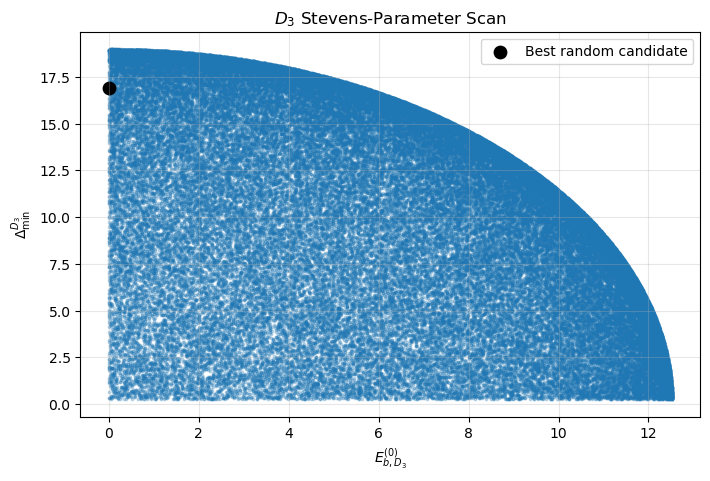

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(Eb_vals, gap_vals, s=3, alpha=0.25)
plt.scatter([Eb_best], [gap_best], s=80, color="k", label="Best random candidate")
plt.xlabel(r"$E_{b,D_3}^{(0)}$")
plt.ylabel(r"$\Delta_{\min}^{D_3}$")
plt.title(r"$D_3$ Stevens-Parameter Scan")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [32]:
def D3_analytic_eigenvalues(Eb, B20, B40, B43):
    """
    Corrected D3 analytic eigenvalues.

    Basis:
    |5/2>, |1/2>, |-1/2>, |3/2>, |-5/2>, |-3/2>
    """

    A = 10*B20 - 60*B40
    D = -8*B20 - 120*B40
    F = -2*B20 - 120*B40
    V = 3*np.sqrt(10)*B43

    # Mixed sector: |5/2> <--> |-5/2>
    a = A - (5/2)*Eb
    d = D + (5/2)*Eb

    lam_minus = (a + d)/2 - np.sqrt(((a - d)/2)**2 + V**2)
    lam_plus  = (a + d)/2 + np.sqrt(((a - d)/2)**2 + V**2)

    # Uncoupled states
    lam_2 = D - (1/2)*Eb
    lam_3 = F + (1/2)*Eb
    lam_4 = A - (3/2)*Eb
    lam_6 = F + (3/2)*Eb

    return np.array([
        lam_minus,
        lam_plus,
        lam_2,
        lam_3,
        lam_4,
        lam_6,
    ])

In [35]:
def plot_D3_analytic_sorted(B20, B40, B43, Eb_min=0, Eb_max=10, n=1000):
    Eb_grid = np.linspace(Eb_min, Eb_max, n)

    levels = np.array([
        D3_analytic_eigenvalues(Eb, B20, B40, B43)
        for Eb in Eb_grid
    ])

    levels_sorted = np.sort(levels, axis=1)

    plt.figure(figsize=(8, 5))

    for i in range(6):
        plt.plot(Eb_grid, levels_sorted[:, i], label=f"Level {i+1}")

    Eb0 = Eb_cross_D3(B20, B40)
    gap = gap_D3(B43)

    if Eb_min <= Eb0 <= Eb_max:
        plt.axvline(Eb0, linestyle="--", color="k",
                    label=rf"$E_b^{{(0)}}={Eb0:.3f}$")

    plt.xlabel(r"$E_b$")
    plt.ylabel("Sorted analytic eigenvalue")
    plt.title(rf"$D_3$ sorted analytic levels, $\Delta_{{min}}={gap:.3f}$")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.show()

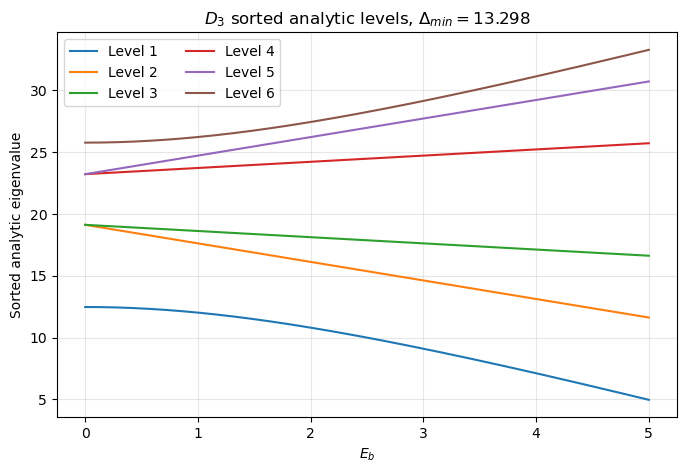

In [36]:
plot_D3_analytic_sorted(
    B20_opt,
    B40_opt,
    B43_opt,
    Eb_min=0,
    Eb_max=5,
)

In [3]:
import sympy as sp

# ============================================================
# Symbolic variables
# ============================================================

lam, Eb = sp.symbols("lambda E_b", real=True)

B20, B40, B22, B42, B44 = sp.symbols(
    "B_2^0 B_4^0 B_2^2 B_4^2 B_4^4",
    real=True
)

# ============================================================
# D2 coefficients
# ============================================================

A = 10*B20 + 60*B40
D = -8*B20 + 120*B40
F = -2*B20 - 180*B40

P = sp.sqrt(10)*B22 + 9*sp.sqrt(10)*B42
Q = 3*sp.sqrt(2)*B22 - 15*sp.sqrt(2)*B42
C = 12*sp.sqrt(5)*B44

# ============================================================
# Field-dependent D2 blocks
# ============================================================

H1 = sp.Matrix([
    [A - sp.Rational(5, 2)*Eb, P, C],
    [P, D - sp.Rational(1, 2)*Eb, Q],
    [C, Q, F + sp.Rational(3, 2)*Eb]
])

H2 = sp.Matrix([
    [A + sp.Rational(5, 2)*Eb, P, C],
    [P, D + sp.Rational(1, 2)*Eb, Q],
    [C, Q, F - sp.Rational(3, 2)*Eb]
])

# ============================================================
# Characteristic polynomials
# det(H - lambda I) = 0
# ============================================================

charpoly_H1 = sp.factor((H1 - lam*sp.eye(3)).det())
charpoly_H2 = sp.factor((H2 - lam*sp.eye(3)).det())

print("Characteristic polynomial for block 1:")
sp.pprint(charpoly_H1)

print("\nCharacteristic polynomial for block 2:")
sp.pprint(charpoly_H2)

Characteristic polynomial for block 1:
        3             2               2              2                 2       ↪
1280⋅B⁰₂  + 103680⋅B⁰₂ ⋅B⁰₄ - 1200⋅B⁰₂ ⋅E_b + 672⋅B⁰₂ ⋅λ - 1280⋅B⁰₂⋅B²₂  + 172 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪                                 2                                   2        ↪
↪ 80⋅B⁰₂⋅B²₂⋅B²₄ - 1152000⋅B⁰₂⋅B⁰₄  - 7680⋅B⁰₂⋅B⁰₄⋅E_b - 23040⋅B⁰₂⋅B²₄  + 4608 ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪          2              2                           2               2        ↪
↪ 0⋅B⁰₂⋅B⁴₄  + 160⋅B⁰₂⋅E_b  - 192⋅B⁰₂⋅E_b⋅λ + 5760⋅B²₂ ⋅B⁰₄ + 5760⋅B²₂ ⋅B⁴₄ +  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                   

In [4]:
# ============================================================
# Convert to standard polynomial form in lambda
# ============================================================

poly_H1 = sp.Poly(sp.expand(charpoly_H1), lam)
poly_H2 = sp.Poly(sp.expand(charpoly_H2), lam)

print("Block 1 polynomial coefficients:")
print(poly_H1.all_coeffs())

print("\nBlock 2 polynomial coefficients:")
print(poly_H2.all_coeffs())

Block 1 polynomial coefficients:
[-1, -3*E_b/2, 84*B_2^0**2 - 24*B_2^0*E_b + 28*B_2^2**2 + 25200*B_4^0**2 - 480*B_4^0*E_b + 1260*B_4^2**2 + 720*B_4^4**2 + 13*E_b**2/4, 160*B_2^0**3 + 12960*B_2^0**2*B_4^0 - 150*B_2^0**2*E_b - 160*B_2^0*B_2^2**2 + 2160*B_2^0*B_2^2*B_4^2 - 144000*B_2^0*B_4^0**2 - 960*B_2^0*B_4^0*E_b - 2880*B_2^0*B_4^2**2 + 5760*B_2^0*B_4^4**2 + 20*B_2^0*E_b**2 + 720*B_2^2**2*B_4^0 + 720*B_2^2**2*B_4^4 + 30*B_2^2**2*E_b + 43200*B_2^2*B_4^0*B_4^2 + 2880*B_2^2*B_4^2*B_4^4 - 720*B_2^2*B_4^2*E_b - 1296000*B_4^0**3 + 70200*B_4^0**2*E_b + 118800*B_4^0*B_4^2**2 - 86400*B_4^0*B_4^4**2 - 720*B_4^0*E_b**2 - 32400*B_4^2**2*B_4^4 - 90*B_4^2**2*E_b + 360*B_4^4**2*E_b + 15*E_b**3/8]

Block 2 polynomial coefficients:
[-1, 3*E_b/2, 84*B_2^0**2 + 24*B_2^0*E_b + 28*B_2^2**2 + 25200*B_4^0**2 + 480*B_4^0*E_b + 1260*B_4^2**2 + 720*B_4^4**2 + 13*E_b**2/4, 160*B_2^0**3 + 12960*B_2^0**2*B_4^0 + 150*B_2^0**2*E_b - 160*B_2^0*B_2^2**2 + 2160*B_2^0*B_2^2*B_4^2 - 144000*B_2^0*B_4^0**2 + 960*B_2^0*B_4^

In [5]:
charpoly_H1_clean = sp.factor((lam*sp.eye(3) - H1).det())
charpoly_H2_clean = sp.factor((lam*sp.eye(3) - H2).det())

poly_H1_clean = sp.Poly(sp.expand(charpoly_H1_clean), lam)
poly_H2_clean = sp.Poly(sp.expand(charpoly_H2_clean), lam)

print("Clean cubic for block 1:")
sp.pprint(poly_H1_clean.as_expr())

print("\nCoefficients [1, a, b, c] for block 1:")
sp.pprint(poly_H1_clean.all_coeffs())

print("\nClean cubic for block 2:")
sp.pprint(poly_H2_clean.as_expr())

print("\nCoefficients [1, a, b, c] for block 2:")
sp.pprint(poly_H2_clean.all_coeffs())

Clean cubic for block 1:
                                                                               ↪
         3            2              2                  2                      ↪
- 160⋅B⁰₂  - 12960⋅B⁰₂ ⋅B⁰₄ + 150⋅B⁰₂ ⋅E_b + 160⋅B⁰₂⋅B²₂  - 2160⋅B⁰₂⋅B²₂⋅B²₄ + ↪
                                                                               ↪

↪                                                                              ↪
↪                2                                 2               2           ↪
↪  144000⋅B⁰₂⋅B⁰₄  + 960⋅B⁰₂⋅B⁰₄⋅E_b + 2880⋅B⁰₂⋅B²₄  - 5760⋅B⁰₂⋅B⁴₄  - 20⋅B⁰₂⋅ ↪
↪                                                                              ↪

↪                                                                              ↪
↪    2          2              2             2                                 ↪
↪ E_b  - 720⋅B²₂ ⋅B⁰₄ - 720⋅B²₂ ⋅B⁴₄ - 30⋅B²₂ ⋅E_b - 43200⋅B²₂⋅B⁰₄⋅B²₄ - 2880⋅ ↪
↪                                                                              ↪



In [6]:
# ============================================================
# Cleaner symbolic form using e1, e2, e3
# ============================================================

e1, e2, e3 = sp.symbols("e_1 e_2 e_3", real=True)

H_generic = sp.Matrix([
    [e1, P, C],
    [P, e2, Q],
    [C, Q, e3]
])

char_generic = sp.factor((lam*sp.eye(3) - H_generic).det())
poly_generic = sp.Poly(sp.expand(char_generic), lam)

print("Generic D2 cubic:")
sp.pprint(char_generic)

print("\nGeneric coefficients [1, a, b, c]:")
sp.pprint(poly_generic.all_coeffs())

Generic D2 cubic:
         2             2            2            2                             ↪
- 720⋅B²₂ ⋅B⁴₄ + 18⋅B²₂ ⋅e₁ + 10⋅B²₂ ⋅e₃ - 28⋅B²₂ ⋅λ - 2880⋅B²₂⋅B²₄⋅B⁴₄ - 180⋅ ↪

↪                                        2              2             2        ↪
↪ B²₂⋅B²₄⋅e₁ + 180⋅B²₂⋅B²₄⋅e₃ + 32400⋅B²₄ ⋅B⁴₄ + 450⋅B²₄ ⋅e₁ + 810⋅B²₄ ⋅e₃ - 1 ↪

↪        2            2             2                                        2 ↪
↪ 260⋅B²₄ ⋅λ + 720⋅B⁴₄ ⋅e₂ - 720⋅B⁴₄ ⋅λ - e₁⋅e₂⋅e₃ + e₁⋅e₂⋅λ + e₁⋅e₃⋅λ - e₁⋅λ  ↪

↪                  2       2    3
↪  + e₂⋅e₃⋅λ - e₂⋅λ  - e₃⋅λ  + λ 

Generic coefficients [1, a, b, c]:
⎡                          2           2          2                            ↪
⎣1, -e₁ - e₂ - e₃, - 28⋅B²₂  - 1260⋅B²₄  - 720⋅B⁴₄  + e₁⋅e₂ + e₁⋅e₃ + e₂⋅e₃, - ↪

↪         2             2            2                                         ↪
↪  720⋅B²₂ ⋅B⁴₄ + 18⋅B²₂ ⋅e₁ + 10⋅B²₂ ⋅e₃ - 2880⋅B²₂⋅B²₄⋅B⁴₄ - 180⋅B²₂⋅B²₄⋅e₁  ↪

↪                             2              2             2   

In [7]:
subs_block1 = {
    e1: A - sp.Rational(5, 2)*Eb,
    e2: D - sp.Rational(1, 2)*Eb,
    e3: F + sp.Rational(3, 2)*Eb
}

char_block1_compact = sp.factor(char_generic.subs(subs_block1))

print("Compact block 1 cubic:")
sp.pprint(char_block1_compact)

Compact block 1 cubic:
 ⎛        3             2               2              2                 2     ↪
-⎝1280⋅B⁰₂  + 103680⋅B⁰₂ ⋅B⁰₄ - 1200⋅B⁰₂ ⋅E_b + 672⋅B⁰₂ ⋅λ - 1280⋅B⁰₂⋅B²₂  + 1 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪                                   2                                   2      ↪
↪ 7280⋅B⁰₂⋅B²₂⋅B²₄ - 1152000⋅B⁰₂⋅B⁰₄  - 7680⋅B⁰₂⋅B⁰₄⋅E_b - 23040⋅B⁰₂⋅B²₄  + 46 ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪            2              2                           2               2      ↪
↪ 080⋅B⁰₂⋅B⁴₄  + 160⋅B⁰₂⋅E_b  - 192⋅B⁰₂⋅E_b⋅λ + 5760⋅B²₂ ⋅B⁰₄ + 5760⋅B²₂ ⋅B⁴₄  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪ 

In [8]:
subs_block2 = {
    e1: A + sp.Rational(5, 2)*Eb,
    e2: D + sp.Rational(1, 2)*Eb,
    e3: F - sp.Rational(3, 2)*Eb
}

char_block2_compact = sp.factor(char_generic.subs(subs_block2))

print("Compact block 2 cubic:")
sp.pprint(char_block2_compact)

Compact block 2 cubic:
 ⎛        3             2               2              2                 2     ↪
-⎝1280⋅B⁰₂  + 103680⋅B⁰₂ ⋅B⁰₄ + 1200⋅B⁰₂ ⋅E_b + 672⋅B⁰₂ ⋅λ - 1280⋅B⁰₂⋅B²₂  + 1 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪                                   2                                   2      ↪
↪ 7280⋅B⁰₂⋅B²₂⋅B²₄ - 1152000⋅B⁰₂⋅B⁰₄  + 7680⋅B⁰₂⋅B⁰₄⋅E_b - 23040⋅B⁰₂⋅B²₄  + 46 ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪            2              2                           2               2      ↪
↪ 080⋅B⁰₂⋅B⁴₄  + 160⋅B⁰₂⋅E_b  + 192⋅B⁰₂⋅E_b⋅λ + 5760⋅B²₂ ⋅B⁰₄ + 5760⋅B²₂ ⋅B⁴₄  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪ 

In [9]:
# ============================================================
# Formal analytical roots
# Warning: these expressions can be extremely long
# ============================================================

roots_H1 = sp.solve(charpoly_H1_clean, lam)
roots_H2 = sp.solve(charpoly_H2_clean, lam)

print("Formal eigenvalues for block 1:")
for r in roots_H1:
    sp.pprint(r)

print("\nFormal eigenvalues for block 2:")
for r in roots_H2:
    sp.pprint(r)

Formal eigenvalues for block 1:
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
  E_b                                                                          ↪
- ─── - ─────────────────────────────────────────────────────────────────────

In [10]:
# ============================================================
# Formal analytical roots + common subexpression elimination
# ============================================================

roots_H1 = sp.solve(charpoly_H1_clean, lam)
roots_H2 = sp.solve(charpoly_H2_clean, lam)

# Apply CSE to all three roots together
replacements_H1, reduced_roots_H1 = sp.cse(
    roots_H1,
    symbols=sp.numbered_symbols("a")
)

replacements_H2, reduced_roots_H2 = sp.cse(
    roots_H2,
    symbols=sp.numbered_symbols("b")
)

print("\n==============================")
print("Block 1 repeated definitions")
print("==============================")
for var, expr in replacements_H1:
    print(f"{sp.latex(var)} = {sp.latex(expr)}")

print("\n==============================")
print("Block 1 eigenvalues")
print("==============================")
for i, root in enumerate(reduced_roots_H1, start=1):
    print(f"lambda_{{1,{i}}} = {sp.latex(root)}")


print("\n==============================")
print("Block 2 repeated definitions")
print("==============================")
for var, expr in replacements_H2:
    print(f"{sp.latex(var)} = {sp.latex(expr)}")

print("\n==============================")
print("Block 2 eigenvalues")
print("==============================")
for i, root in enumerate(reduced_roots_H2, start=1):
    print(f"lambda_{{2,{i}}} = {sp.latex(root)}")


Block 1 repeated definitions
a_{0} = \frac{E_{b}}{2}
a_{1} = \left(B^{0}_{2}\right)^{3}
a_{2} = \left(B^{0}_{4}\right)^{3}
a_{3} = E_{b}^{3}
a_{4} = B^{2}_{2} B^{2}_{4}
a_{5} = B^{0}_{2} a_{4}
a_{6} = B^{0}_{4} a_{4}
a_{7} = B^{4}_{4} a_{4}
a_{8} = \left(B^{2}_{2}\right)^{2}
a_{9} = \left(B^{0}_{4}\right)^{2}
a_{10} = \left(B^{2}_{4}\right)^{2}
a_{11} = \left(B^{4}_{4}\right)^{2}
a_{12} = B^{0}_{2} a_{11}
a_{13} = E_{b}^{2}
a_{14} = B^{0}_{2} a_{13}
a_{15} = \left(B^{0}_{2}\right)^{2}
a_{16} = B^{0}_{4} a_{15}
a_{17} = 9720 a_{8}
a_{18} = E_{b} a_{8}
a_{19} = B^{0}_{4} a_{10}
a_{20} = E_{b} a_{9}
a_{21} = E_{b} a_{11}
a_{22} = E_{b} \left(24 B^{0}_{2} E_{b} + 480 B^{0}_{4} E_{b} - 1260 a_{10} - 720 a_{11} - \frac{13 a_{13}}{4} - 84 a_{15} - 28 a_{8} - 25200 a_{9}\right)
a_{23} = - 72 B^{0}_{2} E_{b} - 1440 B^{0}_{4} E_{b} + 3780 a_{10} + 2160 a_{11} + 12 a_{13} + 252 a_{15} + 84 a_{8} + 75600 a_{9}
a_{24} = 19440 a_{8}
a_{25} = \sqrt[3]{12960 B^{0}_{2} B^{0}_{4} E_{b} + 38880 B^{0}_{2

In [11]:
import sympy as sp

# ============================================================
# Symbols
# ============================================================

Eb = sp.symbols("E_b", real=True)

B20, B40, B22, B42, B44 = sp.symbols(
    "B_2^0 B_4^0 B_2^2 B_4^2 B_4^4",
    real=True
)

# ============================================================
# D2 coefficients
# ============================================================

A = 10*B20 + 60*B40
D = -8*B20 + 120*B40
F = -2*B20 - 180*B40

P = sp.sqrt(10)*B22 + 9*sp.sqrt(10)*B42
Q = 3*sp.sqrt(2)*B22 - 15*sp.sqrt(2)*B42
C = 12*sp.sqrt(5)*B44

# ============================================================
# Bare diagonal energies
# Block 1: |5/2>, |1/2>, |-3/2>
# Block 2: |-5/2>, |-1/2>, |3/2>
# ============================================================

E1_A = A - sp.Rational(5, 2)*Eb
E1_D = D - sp.Rational(1, 2)*Eb
E1_F = F + sp.Rational(3, 2)*Eb

E2_A = A + sp.Rational(5, 2)*Eb
E2_D = D + sp.Rational(1, 2)*Eb
E2_F = F - sp.Rational(3, 2)*Eb

# ============================================================
# Function to solve bare crossing field
# ============================================================

def bare_crossing(E_left, E_right):
    sol = sp.solve(sp.Eq(E_left, E_right), Eb)
    return sp.simplify(sol[0])

# ============================================================
# Block 1 bare crossings
# ============================================================

Eb_AD_1 = bare_crossing(E1_A, E1_D)
Eb_AF_1 = bare_crossing(E1_A, E1_F)
Eb_DF_1 = bare_crossing(E1_D, E1_F)

# ============================================================
# Block 2 bare crossings
# ============================================================

Eb_AD_2 = bare_crossing(E2_A, E2_D)
Eb_AF_2 = bare_crossing(E2_A, E2_F)
Eb_DF_2 = bare_crossing(E2_D, E2_F)

print("================================")
print("D2 bare crossing fields")
print("================================")

crossings = {
    "Block 1: A-D": Eb_AD_1,
    "Block 1: A-F": Eb_AF_1,
    "Block 1: D-F": Eb_DF_1,
    "Block 2: A-D": Eb_AD_2,
    "Block 2: A-F": Eb_AF_2,
    "Block 2: D-F": Eb_DF_2,
}

for name, expr in crossings.items():
    print(f"\n{name}")
    print("SymPy:")
    sp.pprint(expr)
    print("LaTeX:")
    print(sp.latex(expr))

# ============================================================
# Couplings responsible for each avoided crossing
# ============================================================
# A-D crossing is coupled by P
# D-F crossing is coupled by Q
# A-F crossing is coupled by C
# Approximate two-level avoided-crossing gaps:
# Delta_min = 2 |coupling|
# ============================================================

Delta_AD = 2*sp.Abs(P)
Delta_AF = 2*sp.Abs(C)
Delta_DF = 2*sp.Abs(Q)

print("\n================================")
print("Approximate avoided-crossing gaps")
print("================================")

gaps = {
    "A-D avoided gap": Delta_AD,
    "A-F avoided gap": Delta_AF,
    "D-F avoided gap": Delta_DF,
}

for name, expr in gaps.items():
    print(f"\n{name}")
    print("SymPy:")
    sp.pprint(expr)
    print("LaTeX:")
    print(sp.latex(expr))

# ============================================================
# Expanded gap expressions
# ============================================================

print("\n================================")
print("Expanded avoided-crossing gaps")
print("================================")

print("\nDelta_AD = 2|P|")
print(sp.latex(sp.simplify(Delta_AD)))

print("\nDelta_AF = 2|C|")
print(sp.latex(sp.simplify(Delta_AF)))

print("\nDelta_DF = 2|Q|")
print(sp.latex(sp.simplify(Delta_DF)))

D2 bare crossing fields

Block 1: A-D
SymPy:
9⋅B⁰₂ - 30⋅B⁰₄
LaTeX:
9 B^{0}_{2} - 30 B^{0}_{4}

Block 1: A-F
SymPy:
3⋅B⁰₂ + 60⋅B⁰₄
LaTeX:
3 B^{0}_{2} + 60 B^{0}_{4}

Block 1: D-F
SymPy:
-3⋅B⁰₂ + 150⋅B⁰₄
LaTeX:
- 3 B^{0}_{2} + 150 B^{0}_{4}

Block 2: A-D
SymPy:
-9⋅B⁰₂ + 30⋅B⁰₄
LaTeX:
- 9 B^{0}_{2} + 30 B^{0}_{4}

Block 2: A-F
SymPy:
-3⋅B⁰₂ - 60⋅B⁰₄
LaTeX:
- 3 B^{0}_{2} - 60 B^{0}_{4}

Block 2: D-F
SymPy:
3⋅B⁰₂ - 150⋅B⁰₄
LaTeX:
3 B^{0}_{2} - 150 B^{0}_{4}

Approximate avoided-crossing gaps

A-D avoided gap
SymPy:
2⋅│√10⋅B²₂ + 9⋅√10⋅B²₄│
LaTeX:
2 \left|{\sqrt{10} B^{2}_{2} + 9 \sqrt{10} B^{2}_{4}}\right|

A-F avoided gap
SymPy:
24⋅√5⋅│B⁴₄│
LaTeX:
24 \sqrt{5} \left|{B^{4}_{4}}\right|

D-F avoided gap
SymPy:
2⋅│3⋅√2⋅B²₂ - 15⋅√2⋅B²₄│
LaTeX:
2 \left|{3 \sqrt{2} B^{2}_{2} - 15 \sqrt{2} B^{2}_{4}}\right|

Expanded avoided-crossing gaps

Delta_AD = 2|P|
2 \sqrt{10} \left|{B^{2}_{2} + 9 B^{2}_{4}}\right|

Delta_AF = 2|C|
24 \sqrt{5} \left|{B^{4}_{4}}\right|

Delta_DF = 2|Q|
6 \sqrt{2} \left|{B^{2}